## Q3 — Which player has the highest number of wins?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load

IN_DIR = "cleaned_data"

event = pd.read_parquet(f"{IN_DIR}/event.parquet")
home = pd.read_parquet(f"{IN_DIR}/home_team.parquet")
away = pd.read_parquet(f"{IN_DIR}/away_team.parquet")

In [3]:
# Build a match-level winner table
# winner_code: 1 = home_team won, 2 = away_team won
completed = event.loc[(event['winner_code'].notna()) & (event["score_ready"]) , ['match_id', 'winner_code']]
 
home_wins = (completed[completed['winner_code'] == 1]
             .merge(home[['match_id', 'player_id', 'full_name']], on='match_id', how='left'))
away_wins = (completed[completed['winner_code'] == 2]
             .merge(away[['match_id', 'player_id', 'full_name']], on='match_id', how='left'))
 
all_wins = pd.concat([home_wins, away_wins], ignore_index=True)

In [4]:
n_total = len(all_wins)
n_unattributed = int(all_wins['player_id'].isna().sum())
all_wins = all_wins.dropna(subset=['player_id'])
 
print(f"{n_total} completed matches have a recorded winner.")
print(f"{n_unattributed} of those wins can't be attributed to a specific player "
      "(the winning side's player row is missing from home_team/away_team) and are excluded.")
print(f"{len(all_wins)} wins remain, attributable to a specific player.\n")

14413 completed matches have a recorded winner.
2739 of those wins can't be attributed to a specific player (the winning side's player row is missing from home_team/away_team) and are excluded.
11674 wins remain, attributable to a specific player.



In [5]:
# Count wins per player
win_counts = (all_wins.groupby(['player_id', 'full_name'])
              .size()
              .reset_index(name='wins')
              .sort_values('wins', ascending=False)
              .reset_index(drop=True))
 
top_player = win_counts.iloc[0]
print(f"Player with the most wins: {top_player['full_name']} — {int(top_player['wins'])} wins")
print()
print(win_counts.head(10).to_string(index=False))
 
win_counts.to_csv('charts\q3_win_counts_all_players.csv', index=False)

Player with the most wins: Popko, Dmitry — 28 wins

 player_id                         full_name  wins
   50901.0                     Popko, Dmitry    28
  231620.0                  Chidekh, Clement    22
  202572.0                     Gengel, Marek    21
  230049.0             Jianu, Filip Cristian    21
   82133.0 Dellien Velasco, Murkel Alejandro    20
   58369.0                        Bolt, Alex    19
  205282.0                 Kužmová, Katarína    19
  238867.0             Ovcharenko, Oleksandr    19
  341818.0                      Faria, Jaime    18
   58515.0                 Collins, Danielle    18


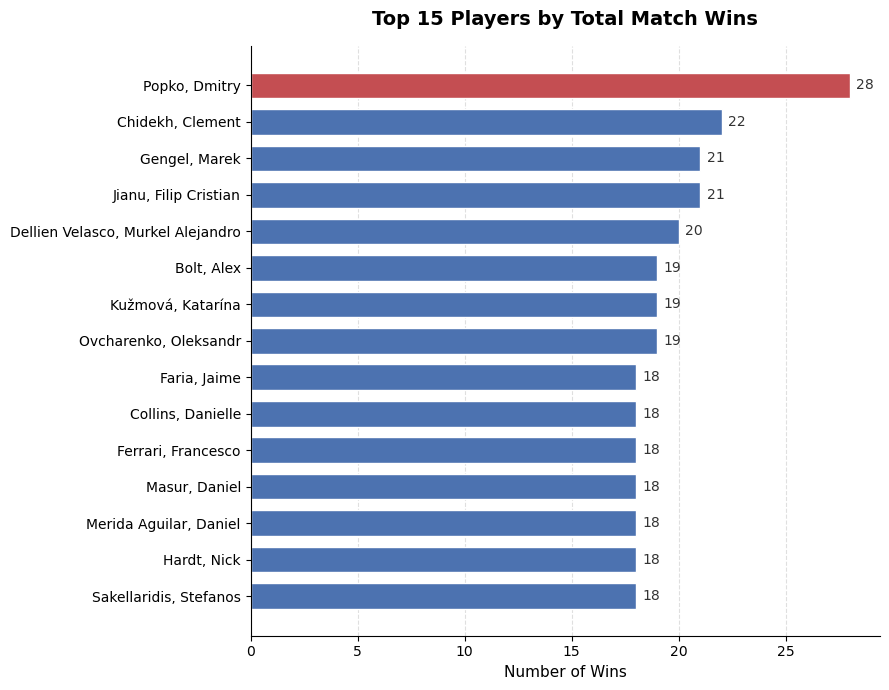

In [7]:
# Visualization
TOP_N = 15
top = win_counts.head(TOP_N).iloc[::-1]  # reverse so #1 sits at the top of the barh
 
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#4C72B0'] * (TOP_N - 1) + ['#C44E52']  # highlight the #1 player
bars = ax.barh(top['full_name'], top['wins'], color=colors, edgecolor='white', height=0.7)
 
for bar, wins in zip(bars, top['wins']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{int(wins)}', va='center', fontsize=10, color='#333333')
 
ax.set_xlabel('Number of Wins', fontsize=11)
ax.set_title(f'Top {TOP_N} Players by Total Match Wins', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('charts\q3_top_players_by_wins.png', dpi=200, bbox_inches='tight')

Popko leads with 28 wins, ahead of Chidekh (22) and Gengel / Jianu (21 each). Based on 11,674 wins linked to a player — 81% of 14,413 completed matches with a winner; 2,739 wins could not be matched to a player row. 

Interpretation: Total wins mix match volume and win rate. Lower-tier schedules (e.g. ITF) can produce higher win totals than fewer, harder matches at higher tiers.

Limitation: Coverage is ~81%, not full. The ranking does not separate how often a player competed from how often they won.